A few galaxy scaling relations: https://arxiv.org/pdf/2109.06301

Find what properties can be accessed form data here: https://www.tng-project.org/data/docs/specifications/ --> Subfind subhalos (Galaxies)

In [1]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

In [3]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = data["Subhalo"]["SubhaloMass"]                #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

#radius where surface brightness profile drops below limit.
def getsubhalo_stellar_photometrics_radius(data):
    hubble_param = gethubble(data)
    raw_subhalo_stellar_photometrics_radius = np.array(data["Subhalo"]["SubhaloStellarPhotometricsRad"])
    subhalo_stellar_photometrics_radius = (raw_subhalo_stellar_photometrics_radius / hubble_param) * units.kpc
    return subhalo_stellar_photometrics_radius

def getsubhalo_stellar_photometrics_massinrad(data):
    hubble_param = gethubble(data)
    raw_subhalo_stellar_photometrics_massinrad = np.array(data["Subhalo"]["SubhaloStellarPhotometricsMassInRad"])
    subhalo_stellar_photometrics_massinrad = (raw_subhalo_stellar_photometrics_massinrad*1e10/hubble_param) * units.Msun
    return subhalo_stellar_photometrics_massinrad

In [4]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    total_mass = getsubhalo_massbytype(data)
    stellar_mass = total_mass[:,4]

    mask = (stellar_mass > 0.0)
    return mask

def getgalaxy_cm(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_cm = getsubhalo_cm(data)
    galaxy_cm = subhalo_cm[galaxy_mask, :]
    return galaxy_cm

def getgalaxy_stellar_photometrics_radius(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_stellar_photometrics_radius = getsubhalo_stellar_photometrics_radius(data)
    galaxy_stellar_photometrics_radius = subhalo_stellar_photometrics_radius[galaxy_mask]
    return galaxy_stellar_photometrics_radius

def getgalaxy_stellar_photometrics_massinrad(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_stellar_photometrics_massinrad = getsubhalo_stellar_photometrics_massinrad(data)
    galaxy_stellar_photometrics_massinrad = subhalo_stellar_photometrics_massinrad[galaxy_mask]
    return galaxy_stellar_photometrics_massinrad

1) Mass-Radius relation
   https://arxiv.org/pdf/2109.06301

In [5]:
def high_mass_radius(mass, amp=0.8):
    radius = amp*(mass**0.39)*units.pc
    return radius

def low_mass_radius(mass, amp=120.0):
    radius = amp*(mass**0.14)*units.pc
    return radius

In [6]:
def plot_mass_radius_relation(): 
    stelpho_radius = getgalaxy_stellar_photometrics_radius(data).to("pc")
    stelpho_massinrad = getgalaxy_stellar_photometrics_massinrad(data)
    stelpho_radius_log = np.log10(stelpho_radius.value)*stelpho_radius.unit
    stelpho_massinrad_log = np.log10(stelpho_massinrad.value)*stelpho_massinrad.unit
    
    #highmgalaxy_mass = np.logspace(np.log10(9*stelpho_massinrad.value), np.log10(12.2*stelpho_massinrad.value), 100)*stelpho_massinrad.unit
    #high_mass_log = np.log10(high_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    high_mass_log = np.log10(high_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    low_mass_log = np.log10(low_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    
    plt.scatter(stelpho_massinrad_log, stelpho_radius_log, s=1, c="blue", label="Data", alpha=0.3)
    plt.plot(stelpho_massinrad_log, high_mass_log, c="red", label="High-mass galaxy fit")
    plt.plot(stelpho_massinrad_log, low_mass_log, c="green", label="Low-mass galaxy fit")
    
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    plt.xscale("linear")
    plt.yscale("linear")
    
    plt.legend()
    plt.show()

C:\Users\niels\AppData\Local\Temp\ipykernel_15024\3964173853.py:4: RuntimeWarning: divide by zero encountered in log10
  stelpho_radius_log = np.log10(stelpho_radius.value)*stelpho_radius.unit
C:\Users\niels\AppData\Local\Temp\ipykernel_15024\3964173853.py:5: RuntimeWarning: divide by zero encountered in log10
  stelpho_massinrad_log = np.log10(stelpho_massinrad.value)*stelpho_massinrad.unit
C:\Users\niels\AppData\Local\Temp\ipykernel_15024\3964173853.py:9: RuntimeWarning: divide by zero encountered in log10
  high_mass_log = np.log10(high_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
C:\Users\niels\AppData\Local\Temp\ipykernel_15024\3964173853.py:10: RuntimeWarning: divide by zero encountered in log10
  low_mass_log = np.log10(low_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit


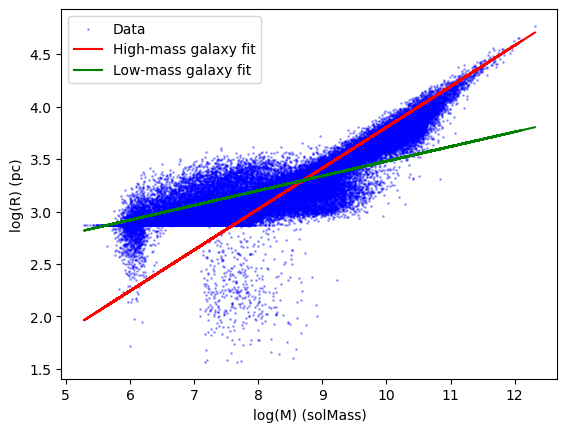

In [7]:
plot_mass_radius_relation()

Data shows the mass-radius curve as explained in the literature https://arxiv.org/pdf/2109.06301, part 5
The horizontal line at almost 1kpc seems to be a 
com_dist = com_dist[com_dist<=r_uppercutoff]

In [8]:
def high_m_scaling():
    stelpho_radius = getgalaxy_stellar_photometrics_radius(data).to("pc")
    stelpho_massinrad = getgalaxy_stellar_photometrics_massinrad(data)
    
    #recreate figure from paper
    m_cutoff = 1.0e9*units.Msun
    mask_ids = stelpho_massinrad>=m_cutoff
    
    stelpho_massinrad = stelpho_massinrad[mask_ids]
    stelpho_radius = stelpho_radius[mask_ids]
    
    stelpho_radius_log = np.log10(stelpho_radius.value)*stelpho_radius.unit
    stelpho_massinrad_log = np.log10(stelpho_massinrad.value)*stelpho_massinrad.unit
    
    #highmgalaxy_mass = np.logspace(np.log10(9*stelpho_massinrad.value), np.log10(12.2*stelpho_massinrad.value), 100)*stelpho_massinrad.unit
    #high_mass_log = np.log10(high_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    high_mass_log = np.log10(high_mass_radius(stelpho_massinrad, amp=0.6).value)*stelpho_radius.unit
    low_mass_log = np.log10(low_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    
    plt.scatter(stelpho_massinrad_log, stelpho_radius_log, s=1, c="blue", label="Data", alpha=0.3)
    plt.plot(stelpho_massinrad_log, high_mass_log, c="red", label="High-mass galaxy fit: R∝$M^{0.39}$")
    #plt.plot(stelpho_massinrad_log, low_mass_log, c="green", label="Low-mass galaxy fit")
    
    plt.title(f"Mass-radius relation for high-mass galaxies")
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    plt.xscale("linear")
    plt.yscale("linear")
    
    plt.legend()
    plt.show()

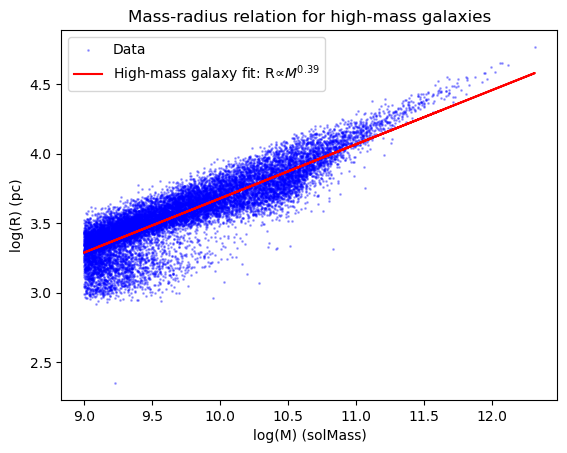

In [9]:
high_m_scaling()

In [10]:
def high_mass_radius_log(masslog, amp):
    mass = 10**masslog
    radius = amp*(mass**0.39)
    return np.log10(radius)

def high_m_scaling_fit():
    stelpho_radius = getgalaxy_stellar_photometrics_radius(data).to("pc")
    stelpho_massinrad = getgalaxy_stellar_photometrics_massinrad(data)
    
    #recreate figure from paper
    m_cutoff = 1.0e9*units.Msun
    mask_ids = stelpho_massinrad>=m_cutoff
    
    stelpho_massinrad = stelpho_massinrad[mask_ids]
    stelpho_radius = stelpho_radius[mask_ids]
    
    stelpho_radius_log = np.log10(stelpho_radius.value)*stelpho_radius.unit
    stelpho_massinrad_log = np.log10(stelpho_massinrad.value)*stelpho_massinrad.unit
    
    #highmgalaxy_mass = np.logspace(np.log10(9*stelpho_massinrad.value), np.log10(12.2*stelpho_massinrad.value), 100)*stelpho_massinrad.unit
    #high_mass_log = np.log10(high_mass_radius(stelpho_massinrad).value)*stelpho_radius.unit
    
    popt, pcov = curve_fit(high_mass_radius_log, stelpho_massinrad_log, stelpho_radius_log, p0=0.8)

    high_mass_log = high_mass_radius_log(stelpho_massinrad_log.value, amp=popt[0])*stelpho_radius.unit
    plt.scatter(stelpho_massinrad_log, stelpho_radius_log, s=1, c="blue", label="Data", alpha=0.3)
    plt.plot(stelpho_massinrad_log, high_mass_log, c="red", label="High-mass galaxy fit: R∝$M^{0.39}$")
    #plt.plot(stelpho_massinrad_log, low_mass_log, c="green", label="Low-mass galaxy fit")
    
    plt.title(f"Mass-radius relation for high-mass galaxies")
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    plt.xscale("linear")
    plt.yscale("linear")
    
    plt.legend()
    plt.show()

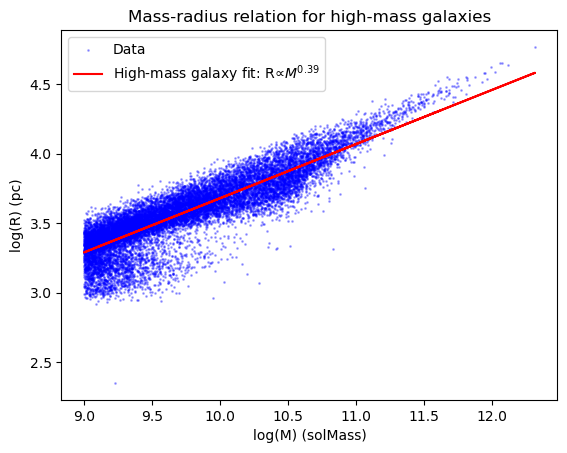

In [11]:
high_m_scaling_fit()

Relation 2: FABER-JACKSON RELATION (correlation between the total luminosity of early-type galaxies (ETGs) L and the central
velocity dispersion of their stars σ), see chapter 2 from the link above

In [27]:
def getsubhalo_veldisp(data):
    raw_onedim_veldisp = data["Subhalo"]["SubhaloVelDisp"]
    onedim_veldisp = raw_onedim_veldisp * units.km / units.s
    return onedim_veldisp

def getgalaxy_veldisp(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_onedim_veldisp = getsubhalo_veldisp(data)
    galaxy_onedim_veldisp = subhalo_onedim_veldisp[galaxy_mask]
    return galaxy_onedim_veldisp

def getgalaxy_stellarphotometrics(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_magnitude = data["Subhalo"]["SubhaloStellarPhotometrics"][:,0]
    galaxy_magnitude = subhalo_magnitude[galaxy_mask]
    return galaxy_magnitude
    

In [44]:
def plot_magnitude_veldisp():
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)
    plt.yscale("log")
    plt.yticks([1, 10, 100])
    plt.xscale("linear")
    plt.scatter(magnitude, veldisp, s=1)

    #L order sigma**4
    plt.title("Faber-Jackson relation")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"σ({veldisp.unit})")
    plt.show()

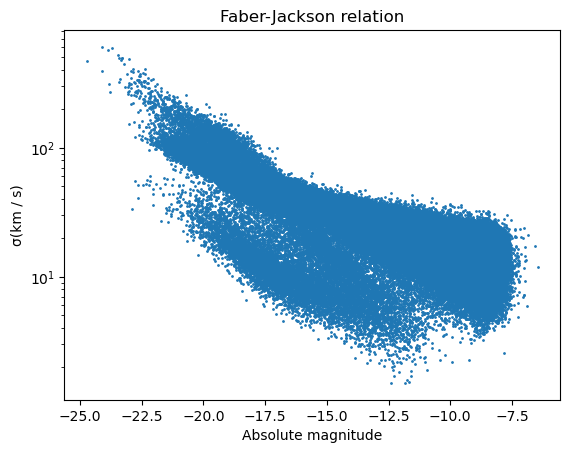

In [45]:
plot_magnitude_veldisp()

In [97]:
def faber_jackson(sigma, amplitude, power):
    luminoscity = amplitude*(sigma**power)
    magn = -2.5*np.log10(luminoscity)
    return magn

#dpi = 200
def plot_magnitude_veldisp_fit():
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)
    plt.yscale("log")
    plt.xscale("linear")
    plt.scatter(magnitude, veldisp, s=1, alpha=0.4, c="blue", label="data")

    power = 4
    veldisp_fit = np.linspace(1, 700, 100) * veldisp.unit
    magn_fit = faber_jackson(veldisp_fit.value, amplitude=1, power=power)
    
    plt.plot(magn_fit, veldisp_fit, c="red", label=f"Faber-Jackson relation: L∝$M^{power}$")
    #L order sigma**4
    plt.title("Faber-Jackson relation")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"σ({veldisp.unit})")
    plt.legend()
    plt.show()

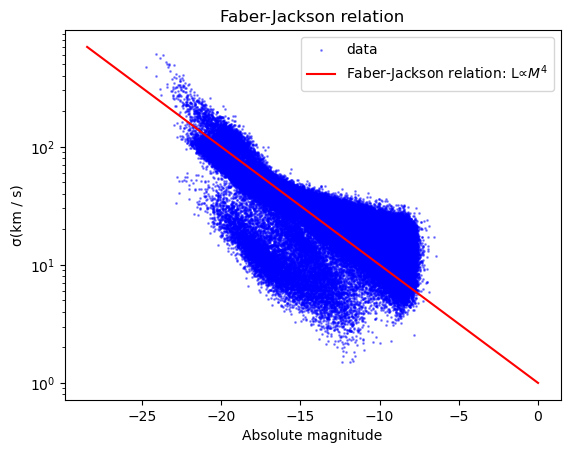

In [98]:
plot_magnitude_veldisp_fit()

Let's also plot the density, to see if most galaxies are located near the line. Wikipedia:
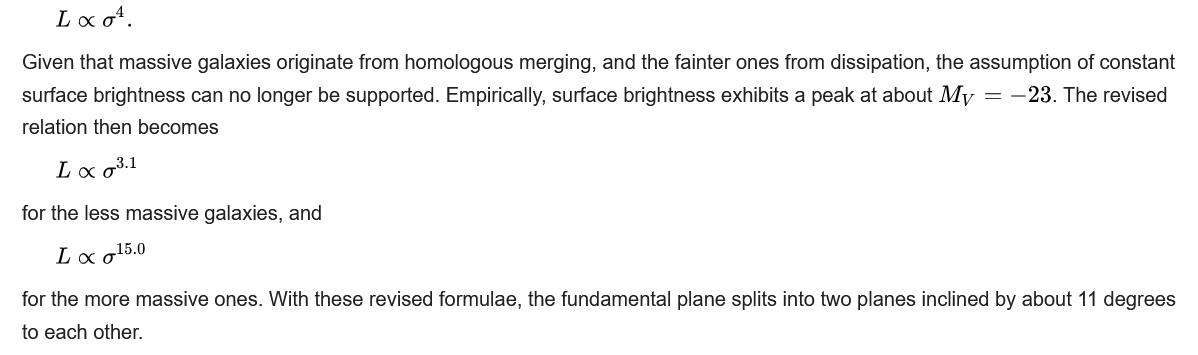

In [99]:
#pip install mpl-scatter-density

   ---------------------------------------- 0.0/749.5 kB ? eta -:--:--
   --------------------------- ------------ 524.3/749.5 kB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 749.5/749.5 kB 4.2 MB/s  0:00:00

   ---------------------------------------- 2/2 [mpl-scatter-density]

Note: you may need to restart the kernel to use updated packages.


In [184]:
import mpl_scatter_density # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap

# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

def using_mpl_scatter_density(fig, x, y):
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    density = ax.scatter_density(x, y, cmap=white_viridis)
    fig.colorbar(density, label='Number of points per pixel')

def plot_magnitude_veldisp_densityfit(data):
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)
    
    fig = plt.figure()
    using_mpl_scatter_density(fig, magnitude, veldisp.value)
    plt.yscale("log")

    power = 15.0
    veldisp_fit = np.linspace(1, 700, 100) * veldisp.unit
    magn_fit = faber_jackson(veldisp_fit.value, amplitude=1e-17, power=power)
    
    plt.plot(magn_fit, veldisp_fit, c="red", label="Faber-Jackson relation: L∝$M^{" + str(power) + "}$")
    #L order sigma**4
    plt.title("Faber-Jackson relation at high mass")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"σ({veldisp.unit})")
    plt.legend()
    plt.show()



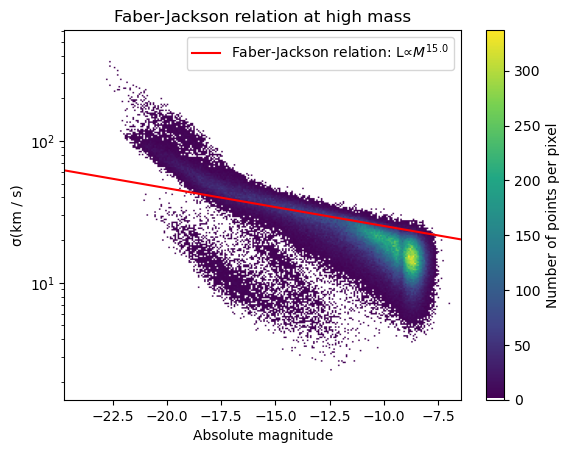

In [185]:
plot_magnitude_veldisp_densityfit(data)

In [197]:
import mpl_scatter_density # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap

# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

def using_mpl_scatter_density(fig, x, y):
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    density = ax.scatter_density(x, y, cmap=white_viridis)
    fig.colorbar(density, label='Number of points per pixel')

def plot_magnitude_veldisp_densityfit_elipse(data):
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)
    
    fig = plt.figure()
    using_mpl_scatter_density(fig, magnitude, veldisp.value)
    plt.yscale("log")

    power = 4.0
    veldisp_fit = np.linspace(1, 700, 100) * veldisp.unit
    magn_fit = faber_jackson(veldisp_fit.value, amplitude=500, power=power)
    
    plt.plot(magn_fit, veldisp_fit, c="red", label="Faber-Jackson relation: L∝$M^{" + str(power) + "}$")
    #L order sigma**4
    plt.title("Faber-Jackson relation for early galaxies")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"σ({veldisp.unit})")
    plt.legend()
    plt.show()



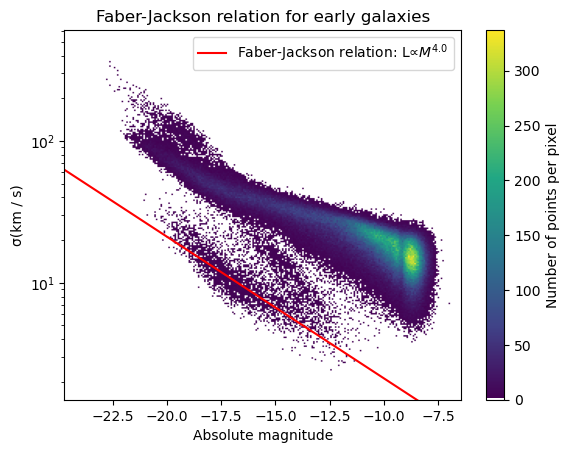

In [198]:
plot_magnitude_veldisp_densityfit_elipse(data)

focus more on dense region. 


In [186]:
def plot_magnitude_veldisp_densityfit_zoom(data):
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)

    magn_cutoff = -12.5
    mask_ids = magnitude>=magn_cutoff
    
    magnitude = magnitude[mask_ids]
    veldisp = veldisp[mask_ids]
    
    fig = plt.figure()
    using_mpl_scatter_density(fig, magnitude, veldisp.value)
    plt.yscale("log")

    power = 3.1
    veldisp_fit = np.linspace(1, 700, 100) * veldisp.unit
    magn_fit = faber_jackson(veldisp_fit.value, amplitude=1.0, power=power)
    
    plt.plot(magn_fit, veldisp_fit, c="red", label="Faber-Jackson relation: L∝$M^{" + str(power) + "}$")
    #L order sigma**4
    plt.title("Faber-Jackson relation at low mass")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"σ({veldisp.unit})")
    plt.legend()
    plt.show()
    

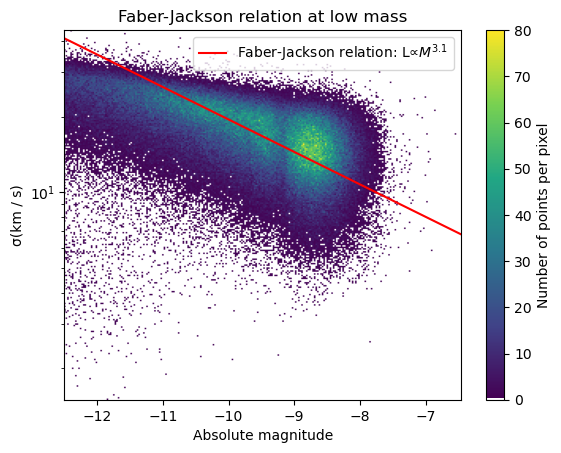

In [187]:
plot_magnitude_veldisp_densityfit_zoom(data)